In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


In [2]:
data_path = '../data'

folders = ['anomaly-free', 'valve1', 'valve2', 'other']

all_dataframes = []

for folder_name in folders:
    folder_path = os.path.join(data_path, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"Missing folder: {folder_path}")
        continue
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                df = pd.read_csv(file_path, sep=';', parse_dates=['datetime'])
                df['anomaly_source'] = folder_name
                df['filename'] = filename
                all_dataframes.append(df)
            except Exception as e:
                print(f"Error reading: {file_path}")
                print(e)

combined_df = pd.concat(all_dataframes, ignore_index=True)

combined_df['anomaly'] = combined_df['anomaly'].fillna(0)
combined_df['changepoint'] = combined_df['changepoint'].fillna(0)

print(f"Data loaded: {len(combined_df)} rows, {len(combined_df.columns)} columns")

Data loaded: 44534 rows, 13 columns


In [3]:
sensor_cols = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
               'Pressure', 'Temperature', 'Thermocouple',
               'Voltage', 'Volume Flow RateRMS']

normal_data = combined_df[combined_df['anomaly'] == 0][sensor_cols]

scaler = StandardScaler()
scaler.fit(normal_data)

combined_df[sensor_cols] = scaler.transform(combined_df[sensor_cols])

print("Normalization complete")
print("\nSensor statistics after normalization:")
print(combined_df[sensor_cols].describe().round(3))

Normalization complete

Sensor statistics after normalization:
       Accelerometer1RMS  Accelerometer2RMS    Current   Pressure  \
count          44534.000          44534.000  44534.000  44534.000   
mean               0.037              0.023     -0.088     -0.015   
std                1.361              1.310      0.995      1.001   
min               -1.228             -1.360     -2.011     -5.166   
25%               -1.103             -1.134     -0.945     -0.113   
50%               -0.532             -0.309     -0.383     -0.113   
75%                0.909              0.925      0.933      1.150   
max                6.304              5.703      1.953      6.203   

       Temperature  Thermocouple    Voltage  Volume Flow RateRMS  
count    44534.000     44534.000  44534.000            44534.000  
mean        -0.111        -0.063      0.006               -0.123  
std          0.999         1.054      0.998                1.013  
min         -1.639        -1.914     -2.615    

In [4]:
combined_df = combined_df.sort_values('datetime').reset_index(drop=True)

window = 50

for sensor in sensor_cols:
    combined_df[f'{sensor}_rolling_mean'] = (
        combined_df[sensor]
        .rolling(window=window, min_periods=1)
        .mean()
    )
    combined_df[f'{sensor}_rolling_std'] = (
        combined_df[sensor]
        .rolling(window=window, min_periods=1)
        .std()
        .fillna(0.01)
    )

print(f"Rolling features computed with window = {window}")
print(f"New column count: {len(combined_df.columns)}")
print(f"\nSample of new columns:")
new_cols = [c for c in combined_df.columns if 'rolling' in c]
print(new_cols[:6])

Rolling features computed with window = 50
New column count: 29

Sample of new columns:
['Accelerometer1RMS_rolling_mean', 'Accelerometer1RMS_rolling_std', 'Accelerometer2RMS_rolling_mean', 'Accelerometer2RMS_rolling_std', 'Current_rolling_mean', 'Current_rolling_std']


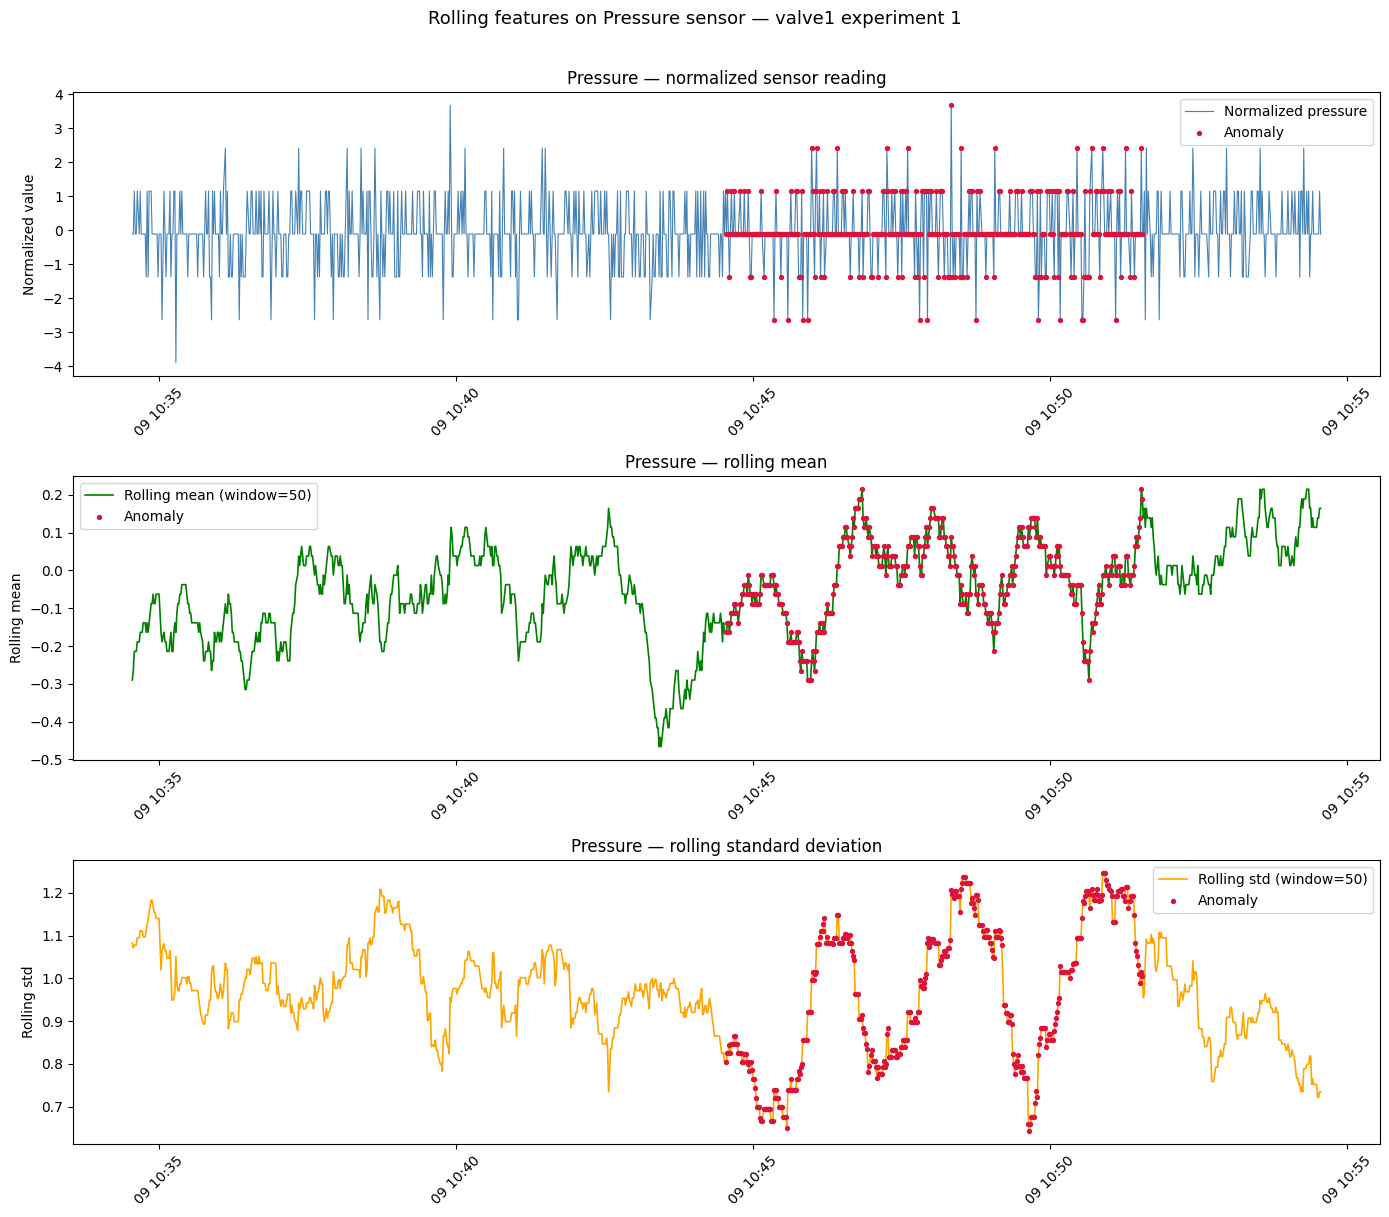

Chart saved to report folder


In [5]:
sample = combined_df[combined_df['filename'] == '1.csv'][
    combined_df['anomaly_source'] == 'valve1'].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(sample['datetime'], sample['Pressure'], 
             color='steelblue', linewidth=0.8, label='Normalized pressure')
anomaly_pts = sample[sample['anomaly'] == 1.0]
axes[0].scatter(anomaly_pts['datetime'], anomaly_pts['Pressure'],
                color='crimson', s=8, zorder=5, label='Anomaly')
axes[0].set_title('Pressure — normalized sensor reading')
axes[0].set_ylabel('Normalized value')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(sample['datetime'], sample['Pressure_rolling_mean'],
             color='green', linewidth=1.2, label='Rolling mean (window=50)')
axes[1].scatter(anomaly_pts['datetime'], 
                anomaly_pts['Pressure_rolling_mean'],
                color='crimson', s=8, zorder=5, label='Anomaly')
axes[1].set_title('Pressure — rolling mean')
axes[1].set_ylabel('Rolling mean')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(sample['datetime'], sample['Pressure_rolling_std'],
             color='orange', linewidth=1.2, label='Rolling std (window=50)')
axes[2].scatter(anomaly_pts['datetime'],
                anomaly_pts['Pressure_rolling_std'],
                color='crimson', s=8, zorder=5, label='Anomaly')
axes[2].set_title('Pressure — rolling standard deviation')
axes[2].set_ylabel('Rolling std')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Rolling features on Pressure sensor — valve1 experiment 1',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../report/rolling_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

## Rolling feature visualization

The rolling mean and rolling standard deviation reveal 
structure that is invisible in the raw signal.

The rolling mean clearly captures the shift in pressure 
baseline when the valve anomaly begins at approximately 
10:44 — dropping sharply before recovering. This mean 
shift is the primary signal that Z-score detection exploits.

The rolling standard deviation increases during the anomalous 
period, indicating higher signal volatility under fault 
conditions. A high rolling std causes the Z-score denominator 
to increase, making individual spike detection more conservative 
— an important characteristic of adaptive thresholding.

Window size of 50 was selected to balance responsiveness 
to sudden changes against stability of the baseline estimate.

In [6]:
output_path = '../data/preprocessed_data.csv'

combined_df.to_csv(output_path, index=False)

print(f"Preprocessed data saved to: {output_path}")
print(f"Total rows: {len(combined_df)}")
print(f"Total columns: {len(combined_df.columns)}")
print(f"\nColumn list:")
for col in combined_df.columns:
    print(f"  {col}")

Preprocessed data saved to: ../data/preprocessed_data.csv
Total rows: 44534
Total columns: 29

Column list:
  datetime
  Accelerometer1RMS
  Accelerometer2RMS
  Current
  Pressure
  Temperature
  Thermocouple
  Voltage
  Volume Flow RateRMS
  anomaly_source
  filename
  anomaly
  changepoint
  Accelerometer1RMS_rolling_mean
  Accelerometer1RMS_rolling_std
  Accelerometer2RMS_rolling_mean
  Accelerometer2RMS_rolling_std
  Current_rolling_mean
  Current_rolling_std
  Pressure_rolling_mean
  Pressure_rolling_std
  Temperature_rolling_mean
  Temperature_rolling_std
  Thermocouple_rolling_mean
  Thermocouple_rolling_std
  Voltage_rolling_mean
  Voltage_rolling_std
  Volume Flow RateRMS_rolling_mean
  Volume Flow RateRMS_rolling_std
